In [1]:
import os
import pickle
import mlflow
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

from tqdm import tqdm
from numpy import sort
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier, plot_importance, XGBRFClassifier
from sklearn.ensemble import RandomForestClassifier
from mlflow.models.signature import infer_signature
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import scale, StandardScaler
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score



In order to make a concrete comparison, I upload all the metrics of the classification after the feature selection to mlflow.
In addition, I upload
1. wo_fs_accuracy: accuracy of the model before feature selection
2. wo_fs_accuracy_cv: average accuracy of a 10-fold cross validation before feature selection
3. wo_fs_std_cv: standard deviation of the accuracies of the folds in the cross validation before feature selection
4. wo_fs_var_cv: variance of the accuracies of the folds in the cross validation before feature selection

5. fs_accuracy: accuracy of the classification after feature selection
6. fs_accuracy_cv: average accuracy of a 10-fold cross validation after feature selection
7. fs_std_cv: standard deviation of the accuracies of the folds in the cross validation after feature selection
8. fs_var_cv: variance of the accuracies of the folds in the cross validation after feature selection

In [2]:
files = ['two_class_raw_1s_no.csv', 'two_class_raw_1s_yo_0.5.csv', 'two_class_raw_1s_yo_0.8.csv', 'two_class_raw_2s_no.csv', 'two_class_raw_2s_yo_0.5.csv', 'two_class_raw_2s_yo_0.8.csv', 
        'two_class_raw_3s_no.csv', 'two_class_raw_3s_yo_0.5.csv', 'two_class_raw_3s_yo_0.8.csv', 'two_class_raw_4s_no.csv', 'two_class_raw_4s_yo_0.5.csv', 'two_class_raw_4s_yo_0.8.csv',
        'two_class_raw_5s_no.csv', 'two_class_raw_5s_yo_0.5.csv', 'two_class_raw_5s_yo_0.8.csv']

In [3]:
data_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/features_data_main/two_class_raw_5s_no.csv'
features = pd.read_csv(data_path)
features.drop(['center_time', 'start_time', 'end_time'], axis=1, inplace=True)


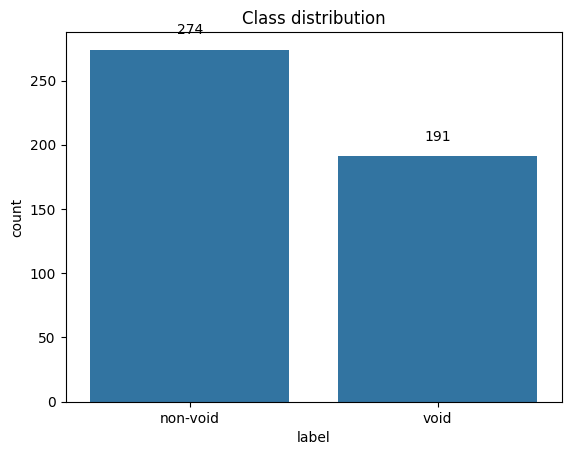

In [4]:
plt.figure()
ax = sns.countplot(x='label',
                   data=features,
                   order=features.label.value_counts().index)

# Manually add value labels
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{int(height)}',
            ha='center', va='bottom')

plt.title('Class distribution')
plt.show()

In [5]:
X = features.drop(columns=['label', 'experiment_id'])
y = features['label']

In [6]:
X = features.drop(columns=['label', 'experiment_id'])
y = features['label']
groups = features['experiment_id']

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

In [7]:
def setup_xgboost_with_imbalance_handling(X_train, y_train, use_smote=False, original_scale_weight=1.27):
    """
    Set up XGBoost with appropriate imbalance handling
    """
    if use_smote:
        print("Applying SMOTE...")
        smote = SMOTE(random_state=42)
        X_balanced, y_balanced = smote.fit_resample(X_train, y_train)
        
        # Check if we still need scale_pos_weight
        unique, counts = np.unique(y_balanced, return_counts=True)
        ratio = counts[0] / counts[1]
        
        if abs(ratio - 1.0) > 0.1:
            scale_weight = ratio
            print(f"Post-SMOTE imbalance detected, using scale_pos_weight: {scale_weight:.3f}")
        else:
            scale_weight = None
            print("Classes balanced after SMOTE, not using scale_pos_weight")
    else:
        print("No SMOTE applied, using original scale_pos_weight")
        X_balanced, y_balanced = X_train, y_train
        scale_weight = original_scale_weight
    
    # Configure XGBoost
    xgb_params = {        
        # 'n_estimators':5,  # initially set to 100
        'max_depth':3,  # initially set to 5
        # 'learning_rate':0.1,
        'subsample':0.5,  # initially set to 0.8
        'colsample_bytree':0.8,
        # 'colsample_bytree':0.5, 
        # 'colsample_bylevel':0.5, 
        # 'colsample_bynode':0.5,
        'random_state':42,
        'eval_metric':'logloss',
        'reg_alpha':0.1,   # L1 regularization
        'reg_lambda':1.0,  # L2 regularization
        # 'verbosity':0
    }
    
    if scale_weight is not None:
        # xgb_params['scale_pos_weight'] = scale_weight
        pass
        
        
        

    
    model = XGBClassifier(**xgb_params)
    
    return model, X_balanced, y_balanced

In [8]:
model, X_train_final, y_train_final = setup_xgboost_with_imbalance_handling(
                                        X_train, 
                                        y_train,
                                        use_smote=False,  # Switch this as needed
                                        original_scale_weight=1.27
                                    )

No SMOTE applied, using original scale_pos_weight


In [9]:
label_encoder = LabelEncoder()
# Encode y_test and y_train
y_train_encoded = label_encoder.fit_transform(y_train_final) 
y_test_encoded = label_encoder.transform(y_test)

Train model with all the features.

In [10]:
eval_set = [(X_train_final, y_train_encoded), (X_test, y_test_encoded)]
# Fit initial model
model.fit(X_train_final, y_train_encoded, eval_set=eval_set, verbose=False)


# make predictions for test data and evaluate
predictions = label_encoder.inverse_transform(model.predict(X_test))
wo_fs_accuracy = accuracy_score(y_test, predictions)
print("Accuracy: %.2f%%" % (wo_fs_accuracy * 100.0))

Accuracy: 76.61%


Classification report of model trained with all the features

In [11]:
report = classification_report(y_test, predictions)

print(report)

              precision    recall  f1-score   support

    non-void       0.76      0.89      0.82        76
        void       0.77      0.56      0.65        48

    accuracy                           0.77       124
   macro avg       0.77      0.73      0.74       124
weighted avg       0.77      0.77      0.76       124



Confusion matrix of model trained with all the features

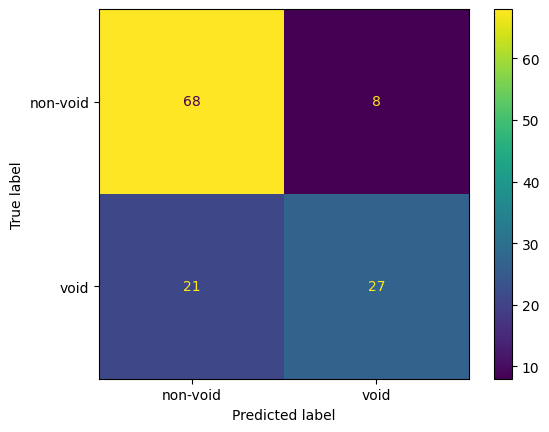

In [12]:
cm = confusion_matrix(y_test, predictions)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['non-void', 'void'])
cm_display.plot()
plt.show()

Loss of model trained on all the features

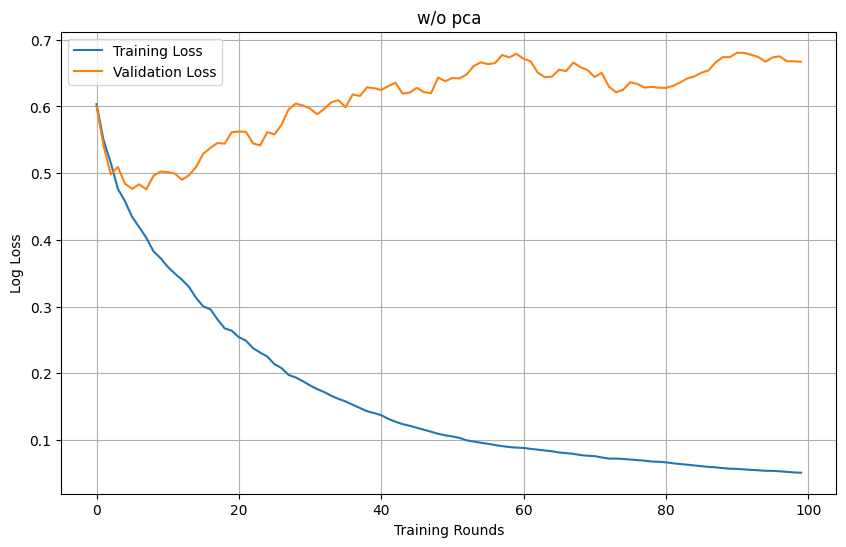

In [13]:
# Retrieve the evaluation results
results = model.evals_result()
train_loss = results['validation_0']['logloss']
test_loss = results['validation_1']['logloss']

# Plot the loss function
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(test_loss, label='Validation Loss')
plt.xlabel('Training Rounds')
plt.ylabel('Log Loss')
plt.title('w/o pca')
plt.legend()
plt.grid(True)
plt.show()

Comparing base models
1. XGBoost
2. RandomForest

Without no parameters

In [14]:
from sklearn.model_selection import cross_val_score
# Perform cross-validation
gkf = GroupKFold(n_splits=10)
cv_scores = cross_val_score(model, X, label_encoder.transform(y), groups=groups, cv=gkf, scoring='accuracy')
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {np.mean(cv_scores) * 100:.2f}%")
print(f"Standard deviation of CV accuracy: {np.std(cv_scores) * 100:.2f}%")
print(f"Variance of CV accuracy: {np.var(cv_scores) * 100:.2f}%")
# cv_scores

wo_fs_accuracy_cv = round (np.mean(cv_scores) * 100, 2)
wo_fs_std_cv = round(np.std(cv_scores) * 100, 2)
wo_fs_var_cv = round(np.var(cv_scores) * 100, 2)

# round to 2 decimal places

Cross-validation scores: [0.84444444 0.74       0.82222222 0.64       0.70454545 0.63636364
 0.5        0.45454545 0.72       0.63265306]
Mean CV accuracy: 66.95%
Standard deviation of CV accuracy: 11.87%
Variance of CV accuracy: 1.41%


In [15]:
from sklearn.model_selection import cross_val_score
# Perform cross-validation
gkf = GroupKFold(n_splits=10)
cv_scores = cross_val_score(RandomForestClassifier(random_state=42, n_estimators=100), X, label_encoder.transform(y), groups=groups, cv=gkf, scoring='accuracy')
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {np.mean(cv_scores) * 100:.2f}%")
print(f"Standard deviation of CV accuracy: {np.std(cv_scores) * 100:.2f}%")
print(f"Variance of CV accuracy: {np.var(cv_scores) * 100:.2f}%")

Cross-validation scores: [0.82222222 0.82       0.8        0.66       0.70454545 0.61363636
 0.43181818 0.65909091 0.84       0.75510204]
Mean CV accuracy: 71.06%
Standard deviation of CV accuracy: 11.98%
Variance of CV accuracy: 1.44%


In [16]:
from sklearn.model_selection import cross_val_score
# Perform cross-validation
gkf = GroupKFold(n_splits=10)
cv_scores = cross_val_score(XGBRFClassifier(random_state=42, n_estimators=100), X, label_encoder.transform(y), groups=groups, cv=gkf, scoring='accuracy')
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {np.mean(cv_scores) * 100:.2f}%")
print(f"Standard deviation of CV accuracy: {np.std(cv_scores) * 100:.2f}%")
print(f"Variance of CV accuracy: {np.var(cv_scores) * 100:.2f}%")

Cross-validation scores: [0.86666667 0.66       0.82222222 0.64       0.70454545 0.65909091
 0.47727273 0.59090909 0.82       0.73469388]
Mean CV accuracy: 69.75%
Standard deviation of CV accuracy: 11.25%
Variance of CV accuracy: 1.27%


## Feature Importance and Feature Selection

In [17]:
# Store results from your threshold testing
results = []
models_info = []

# Fit model using each importance as a threshold
thresholds = sort(model.feature_importances_)
for thresh in thresholds:
	# select features using threshold
	selection = SelectFromModel(model, threshold=thresh, prefit=True)
	select_X_train = selection.transform(X_train_final)


	# train model
	selection_model = XGBClassifier(
		# n_estimators=5,  # initially set to 100
        max_depth=3, # initially set to 5
        # learning_rate=0.1,
        # subsample=0.5,  # initially set to 0.8
        colsample_bytree=0.8,
        # colsample_bytree=0.5,
        # colsample_bylevel=0.5, 
        # colsample_bynode=0.5,
        random_state=42,
        eval_metric='logloss',
        reg_alpha=0.1,   # L1 regularization
        reg_lambda=1.0,  # L2 regularization
        # verbosity=0,
        # original_scale_weight=1.27
	)
	selection_model.fit(select_X_train, y_train_encoded)


	# evaluate model
	select_X_test = selection.transform(X_test)
	predictions = label_encoder.inverse_transform(selection_model.predict(select_X_test))
	accuracy = accuracy_score(y_test, predictions)


	# Store results
	results.append({
		'threshold': thresh,
		'n_features': select_X_train.shape[1],
		'accuracy': accuracy
	})

	models_info.append({
		'threshold': thresh,
		'selector': selection,
		'model': selection_model
	})

# print("Thresh=%.3f, n=%d, Accuracy: %.2f%%" % (thresh, select_X_train.shape[1], accuracy*100.0))
	warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.utils.validation')

/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Find the best configuration. Number of features which give the highest accuracy and the threshold.

In [18]:
# Convert results to DataFrame for easier analysis
results_df = pd.DataFrame(results)

# Find the best configuration
best_idx = results_df['accuracy'].idxmax()
best_config = results_df.loc[best_idx]

print(f"\nBest Configuration:")
print(f"Threshold: {best_config['threshold']:.3f}")
print(f"Number of features: {best_config['n_features']}")
print(f"Accuracy: {best_config['accuracy']:.4f} ({best_config['accuracy']*100:.2f}%)")


Best Configuration:
Threshold: 0.021
Number of features: 8.0
Accuracy: 0.7661 (76.61%)


In [19]:
# Get the best selector and create final training set
best_selector = models_info[best_idx]['selector']
X_train_final_selected = best_selector.transform(X_train_final)
X_test_final_selected = best_selector.transform(X_test)

eval_set = [(X_train_final_selected, y_train_encoded), (X_test_final_selected, y_test_encoded)]

# Train your final model
final_model = XGBClassifier(
        # n_estimators=5,  # initially set to 100
        max_depth=3, # initially set to 5,
        # learning_rate=0.1,
        subsample=0.5,  # initially set to 0.8
        colsample_bytree=0.8,
        # colsample_bytree=0.5,
        # colsample_bylevel=0.5, 
        # colsample_bynode=0.5,
        random_state=42,
        eval_metric='logloss',
        reg_alpha=0.1,   # L1 regularization
        reg_lambda=1.0,  # L2 regularization
        # verbosity=0,
        # original_scale_weight=1.27
)
final_model.fit(X_train_final_selected, y_train_encoded, eval_set=eval_set, verbose=False)

# Final evaluation
final_predictions = label_encoder.inverse_transform(final_model.predict(X_test_final_selected))
fs_accuracy = accuracy_score(y_test, final_predictions)

print(f"\nFinal Model Performance:")
print(f"Features used: {X_train_final_selected.shape[1]}")
print(f"Final Accuracy: {fs_accuracy:.4f} ({fs_accuracy*100:.2f}%)")


Final Model Performance:
Features used: 8
Final Accuracy: 0.7339 (73.39%)


In [20]:
# If you want to see which features were selected
if hasattr(X_train_final, 'columns'):
    selected_features = X_train_final.columns[best_selector.get_support()]
    print(f"\nSelected Features ({len(selected_features)}):")
    for i, feature in enumerate(selected_features, 1):
        print(f"{i}. {feature}")


Selected Features (8):
1. acc_x_std
2. acc_x_range
3. acc_y_std
4. acc_mag_mean
5. acc_mag_rms
6. acc_mag_max
7. acc_mag_spectral_energy
8. gyr_y_permutation_entropy


In [21]:
report = classification_report(y_test, final_predictions)

print(report)

              precision    recall  f1-score   support

    non-void       0.73      0.89      0.80        76
        void       0.74      0.48      0.58        48

    accuracy                           0.73       124
   macro avg       0.74      0.69      0.69       124
weighted avg       0.74      0.73      0.72       124



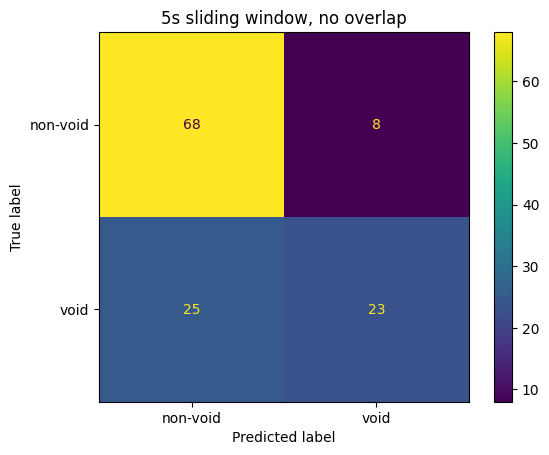

In [22]:
cm = confusion_matrix(y_test, final_predictions)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['non-void', 'void'])
cm_display.plot()
plt.title('5s sliding window, no overlap')
# cm_fig_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/model_plots/wo_pca_two_class_results/cm_5s_0.8.png'
# plt.savefig(cm_fig_path)
plt.show()

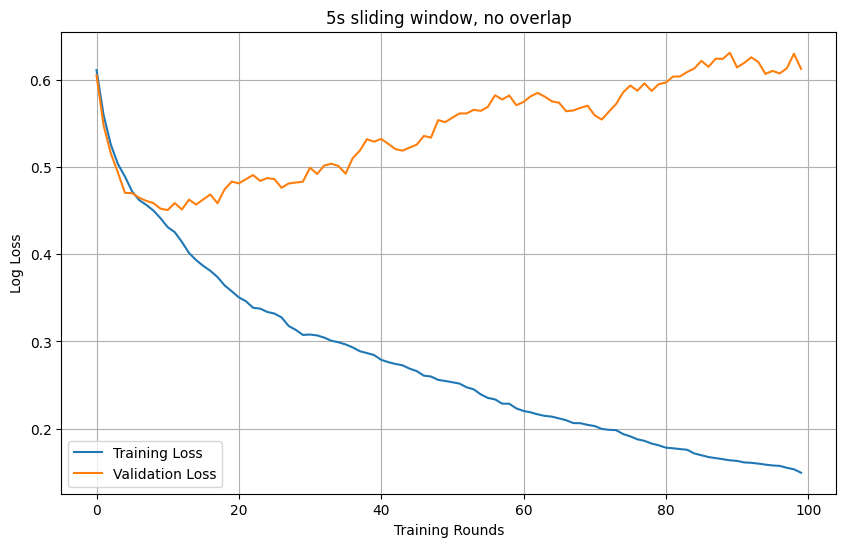

In [23]:
# Retrieve the evaluation results
results = final_model.evals_result()
train_loss = results['validation_0']['logloss']
test_loss = results['validation_1']['logloss']

# Plot the loss function
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(test_loss, label='Validation Loss')
plt.xlabel('Training Rounds')
plt.ylabel('Log Loss')
plt.title('5s sliding window, no overlap')
plt.legend()
plt.grid(True)
# loss_fig_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/model_plots/wo_pca_two_class_results/loss_5s_0.8.png'
# plt.savefig(loss_fig_path)
plt.show()

# Cross Validation

#### XGBClassifier

In [24]:
from sklearn.model_selection import GroupKFold
import numpy as np

gkf = GroupKFold(n_splits=10)
fold_results = []

for fold_num, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
    
    # Encode labels
    y_train_encoded = label_encoder.fit_transform(y_train_fold)
    y_test_encoded = label_encoder.transform(y_test_fold)
    
    X_train_final_selected = best_selector.transform(X_train_fold)
    X_test_final_selected = best_selector.transform(X_test_fold)
    
    # Train model
    final_model.fit(X_train_final_selected, y_train_encoded)
    
    # Evaluate
    predictions = label_encoder.inverse_transform(final_model.predict(X_test_final_selected))
    accuracy = accuracy_score(y_test_fold, predictions)
    
    # Store results
    fold_results.append({
        'fold': fold_num,
        'accuracy': accuracy,
        'train_idx': train_idx,
        'test_idx': test_idx,
        'train_groups': groups[train_idx],
        'test_groups': groups[test_idx]
    })
    
    print(f"Fold {fold_num} Accuracy: {accuracy * 100:.2f}%")

# Find best performing fold
best_fold = max(fold_results, key=lambda x: x['accuracy'])
# print(f"\nBest fold: {best_fold['fold']} with accuracy: {best_fold['accuracy'] * 100:.2f}%")

fs_accuracy_cv = round(np.mean([f['accuracy'] for f in fold_results]) * 100, 2)
fs_std_cv = round(np.std([f['accuracy'] for f in fold_results]) * 100, 2)
fs_var_cv = round(np.var([f['accuracy'] for f in fold_results]) * 100, 2)

print(f"Mean accuracy across all folds: {fs_accuracy_cv}%")
print(f"Standard deviation of accuracy across folds: {fs_std_cv}%")
print(f"Variance of accuracy across folds: {fs_var_cv}%")

Fold 0 Accuracy: 82.22%
Fold 1 Accuracy: 68.00%
Fold 2 Accuracy: 77.78%
Fold 3 Accuracy: 64.00%
Fold 4 Accuracy: 63.64%
Fold 5 Accuracy: 59.09%
Fold 6 Accuracy: 47.73%
Fold 7 Accuracy: 72.73%
Fold 8 Accuracy: 74.00%
Fold 9 Accuracy: 71.43%
Mean accuracy across all folds: 68.06%
Standard deviation of accuracy across folds: 9.45%
Variance of accuracy across folds: 0.89%


#### RandomForest

In [25]:
from sklearn.model_selection import GroupKFold
import numpy as np

gkf = GroupKFold(n_splits=10)
fold_results = []

for fold_num, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
    
    # Encode labels
    y_train_encoded = label_encoder.fit_transform(y_train_fold)
    y_test_encoded = label_encoder.transform(y_test_fold)
    
    X_train_final_selected = best_selector.transform(X_train_fold)
    X_test_final_selected = best_selector.transform(X_test_fold)
    
    # Train model
    model = RandomForestClassifier(random_state=42, n_estimators=100)
    model.fit(X_train_final_selected, y_train_encoded)
    
    # Evaluate
    predictions = label_encoder.inverse_transform(model.predict(X_test_final_selected))
    accuracy = accuracy_score(y_test_fold, predictions)
    
    # Store results
    fold_results.append({
        'fold': fold_num,
        'accuracy': accuracy,
        'train_idx': train_idx,
        'test_idx': test_idx,
        'train_groups': groups[train_idx],
        'test_groups': groups[test_idx]
    })
    
    print(f"Fold {fold_num} Accuracy: {accuracy * 100:.2f}%")

# Find best performing fold
best_fold = max(fold_results, key=lambda x: x['accuracy'])
# print(f"\nBest fold: {best_fold['fold']} with accuracy: {best_fold['accuracy'] * 100:.2f}%")

fs_accuracy_cv = round(np.mean([f['accuracy'] for f in fold_results]) * 100, 2)
fs_std_cv = round(np.std([f['accuracy'] for f in fold_results]) * 100, 2)
fs_var_cv = round(np.var([f['accuracy'] for f in fold_results]) * 100, 2)

print(f"Mean accuracy across all folds: {fs_accuracy_cv}%")
print(f"Standard deviation of accuracy across folds: {fs_std_cv}%")
print(f"Variance of accuracy across folds: {fs_var_cv}%")

Fold 0 Accuracy: 88.89%
Fold 1 Accuracy: 84.00%
Fold 2 Accuracy: 75.56%
Fold 3 Accuracy: 66.00%
Fold 4 Accuracy: 68.18%
Fold 5 Accuracy: 56.82%
Fold 6 Accuracy: 56.82%
Fold 7 Accuracy: 70.45%
Fold 8 Accuracy: 82.00%
Fold 9 Accuracy: 71.43%
Mean accuracy across all folds: 72.01%
Standard deviation of accuracy across folds: 10.28%
Variance of accuracy across folds: 1.06%


#### XGBRFClassifier

In [26]:
from sklearn.model_selection import GroupKFold
import numpy as np

gkf = GroupKFold(n_splits=10)
fold_results = []

for fold_num, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
    
    # Encode labels
    y_train_encoded = label_encoder.fit_transform(y_train_fold)
    y_test_encoded = label_encoder.transform(y_test_fold)
    
    X_train_final_selected = best_selector.transform(X_train_fold)
    X_test_final_selected = best_selector.transform(X_test_fold)
    
    # Train model
    model = XGBRFClassifier(random_state=42, n_estimators=100)
    model.fit(X_train_final_selected, y_train_encoded)
    
    # Evaluate
    predictions = label_encoder.inverse_transform(model.predict(X_test_final_selected))
    accuracy = accuracy_score(y_test_fold, predictions)
    
    # Store results
    fold_results.append({
        'fold': fold_num,
        'accuracy': accuracy,
        'train_idx': train_idx,
        'test_idx': test_idx,
        'train_groups': groups[train_idx],
        'test_groups': groups[test_idx]
    })
    
    print(f"Fold {fold_num} Accuracy: {accuracy * 100:.2f}%")

# Find best performing fold
best_fold = max(fold_results, key=lambda x: x['accuracy'])
# print(f"\nBest fold: {best_fold['fold']} with accuracy: {best_fold['accuracy'] * 100:.2f}%")

fs_accuracy_cv = round(np.mean([f['accuracy'] for f in fold_results]) * 100, 2)
fs_std_cv = round(np.std([f['accuracy'] for f in fold_results]) * 100, 2)
fs_var_cv = round(np.var([f['accuracy'] for f in fold_results]) * 100, 2)

print(f"Mean accuracy across all folds: {fs_accuracy_cv}%")
print(f"Standard deviation of accuracy across folds: {fs_std_cv}%")
print(f"Variance of accuracy across folds: {fs_var_cv}%")

Fold 0 Accuracy: 91.11%
Fold 1 Accuracy: 82.00%
Fold 2 Accuracy: 80.00%
Fold 3 Accuracy: 66.00%
Fold 4 Accuracy: 72.73%
Fold 5 Accuracy: 61.36%
Fold 6 Accuracy: 50.00%
Fold 7 Accuracy: 72.73%
Fold 8 Accuracy: 80.00%
Fold 9 Accuracy: 77.55%
Mean accuracy across all folds: 73.35%
Standard deviation of accuracy across folds: 11.14%
Variance of accuracy across folds: 1.24%


The results i am getting may suggest that since i am using features selected based on the XGBClassifier, the others are not prioritized.

## Upload to MLFlow

In [27]:
report_dict = classification_report(y_test, final_predictions, output_dict=True)
report_dict

{'non-void': {'precision': 0.7311827956989247,
  'recall': 0.8947368421052632,
  'f1-score': 0.8047337278106509,
  'support': 76.0},
 'void': {'precision': 0.7419354838709677,
  'recall': 0.4791666666666667,
  'f1-score': 0.5822784810126582,
  'support': 48.0},
 'accuracy': 0.7338709677419355,
 'macro avg': {'precision': 0.7365591397849462,
  'recall': 0.6869517543859649,
  'f1-score': 0.6935061044116546,
  'support': 124.0},
 'weighted avg': {'precision': 0.7353451266042318,
  'recall': 0.7338709677419355,
  'f1-score': 0.7186220193727182,
  'support': 124.0}}

In [28]:
import mlflow
import mlflow.xgboost
from mlflow.models.signature import infer_signature
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import os

def log_experiment_run(
    model,
    X_test,
    report_dict,
    # loss_fig_path,
    # cm_fig_path,
    # data_path,
    params,
    experiment_name="Posture Detection - Window Size Tuning - Without PCA",
    model_name="XGBoost"
):

    # Set experiment
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment(experiment_name)

    run_name = f"{params.get('window_size', 'NA')}s_win_{int(params.get('overlap', 0.0) * 100)}%_overlap"
    # run_name = f"{params.get('window_size', 'NA')}s_win_{int(params.get('overlap', 0.0) * 100)}%_overlap_{params.get('smote')}" # with smote
    
    del params['window_size']
    del params['overlap']
    del params['smote']

    with mlflow.start_run(run_name=run_name):
        # Log parameters
        mlflow.log_params(params)

        
        
        # Extract individual class metrics (you can rename 'void' and 'non-void' if your class names are different)
        precision_void = report_dict.get("void", {}).get("precision", 0.0)
        recall_void = report_dict.get("void", {}).get("recall", 0.0)
        f1_void = report_dict.get("void", {}).get("f1-score", 0.0)

        precision_non_void = report_dict.get("non-void", {}).get("precision", 0.0)
        recall_non_void = report_dict.get("non-void", {}).get("recall", 0.0)
        f1_non_void = report_dict.get("non-void", {}).get("f1-score", 0.0)


        mlflow.log_metrics({
            "wo_fs_accuracy": wo_fs_accuracy,
            "wo_fs_accuracy_cv": wo_fs_accuracy_cv,
            "wo_fs_std_cv": wo_fs_std_cv,
            "wo_fs_var_cv": wo_fs_var_cv,
                        
            "fs_accuracy": report_dict.get("accuracy", 0.0),
            "fs_accuracy_cv": fs_accuracy_cv,
            "fs_std_cv": fs_std_cv,
            "fs_var_cv": fs_var_cv,
            
            # Void class (e.g., posture change)
            "precision_void": precision_void,
            "recall_void": recall_void,
            "f1_void": f1_void,

            # Non-void class
            "precision_non_void": precision_non_void,
            "recall_non_void": recall_non_void,
            "f1_non_void": f1_non_void,

            # Averages
            "precision_macro": report_dict.get("macro avg", {}).get("precision", 0.0),
            "recall_macro": report_dict.get("macro avg", {}).get("recall", 0.0),
            "f1_score_macro": report_dict.get("macro avg", {}).get("f1-score", 0.0),

            "precision_weighted": report_dict.get("weighted avg", {}).get("precision", 0.0),
            "recall_weighted": report_dict.get("weighted avg", {}).get("recall", 0.0),
            "f1_score_weighted": report_dict.get("weighted avg", {}).get("f1-score", 0.0),
        }) # type: ignore

        # Log model with signature
        # input_example = X_test.iloc[:1]
        input_example = X_test_final_selected[:1]
        signature = infer_signature(X_test_final_selected, model.predict(X_test_final_selected))

        try:
            mlflow.xgboost.log_model(
                xgb_model=model,
                artifact_path=model_name,
                input_example=input_example,
                signature=signature
            )
        except Exception as e:
            print("Error logging model:", e)
        
        # try:
        #     mlflow.log_artifact(cm_fig_path)
        # except Exception as e:
        #     print("Error logging artifact:", e)
            
        # try:
        #     mlflow.log_artifact(loss_fig_path)
        # except Exception as e:
        #     print("Error logging artifact:", e)
        
        # try:    
        #     mlflow.log_artifact(data_path)
        # except Exception as e:
        #     print("Error logging artifact:", e)


In [29]:
params = {        
        'n_estimators':200,
        'max_depth':5,
        'learning_rate':0.1,
        'subsample':0.8,
        'colsample_bytree':0.8,
        'random_state':42,
        'eval_metric':'logloss',
        'reg_alpha':0.1,   # L1 regularization
        'reg_lambda':1.0,  # L2 regularization
        'verbosity':0,
        "original_scale_weight":1.27
    }

In [30]:
from sklearn.metrics import classification_report

# Example parameters
params['window_size'] = 1
params['overlap'] = 0.8
params['smote'] = 'smote'
params['exp_name'] = '1s_0.8'


# y_pred = model.predict(X_test)
report_dict = classification_report(y_test, final_predictions, output_dict=True)

# log_experiment_run(final_model, X_test_final_selected, report_dict, params)